# Lab 4 — MNIST: Learning at Scale

## Task A — Reading the data

MNIST files use the IDX format: a big-endian header followed by raw unsigned bytes.
Label files have an 8-byte header (magic number, count); image files have a 16-byte
header (magic number, count, rows, cols). We skip the header and read the rest as `uint8`.

In [54]:
from pathlib import Path

import numpy as np

DATA_DIR = Path.cwd()
IMAGE_SIZE = 28

def read_labels(filename):
    data = (DATA_DIR / filename).read_bytes()
    return np.frombuffer(data, dtype=np.uint8, offset=8)

def read_images(filename):
    data = (DATA_DIR / filename).read_bytes()
    pixels = np.frombuffer(data, dtype=np.uint8, offset=16)
    return pixels.reshape(-1, IMAGE_SIZE, IMAGE_SIZE)

In [55]:
train_images = read_images("train-images-idx3-ubyte")
train_labels = read_labels("train-labels-idx1-ubyte")
test_images = read_images("t10k-images-idx3-ubyte")
test_labels = read_labels("t10k-labels-idx1-ubyte")

print("train:", train_images.shape, train_labels.shape)
print("test: ", test_images.shape, test_labels.shape)
print("labels:", np.unique(train_labels))
print("pixels:", train_images.min(), "to", train_images.max())
print("first labels:", train_labels[:10])

train: (60000, 28, 28) (60000,)
test:  (10000, 28, 28) (10000,)
labels: [0 1 2 3 4 5 6 7 8 9]
pixels: 0 to 255
first labels: [5 0 4 1 9 2 1 3 1 4]


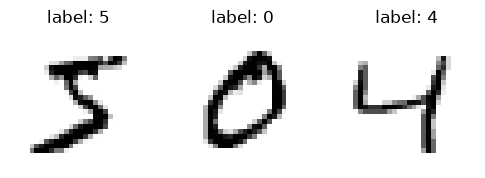

In [56]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(6, 2.5))
for i, ax in enumerate(axes):
    ax.imshow(train_images[i], cmap="gray_r")
    ax.set_title(f"label: {train_labels[i]}")
    ax.axis("off")
plt.show()

### Curating the data

The network expects one row per example, so each 28×28 image is flattened to 784 inputs
and scaled from 0–255 down to 0–1. Each label becomes a one-hot vector of length 10 to match
the 10 softmax outputs (e.g. `3` → `[0,0,0,1,0,0,0,0,0,0]`).

In [57]:
NUM_CLASSES = 10


# Normalizing inputs
def to_inputs(images):
    return images.reshape(len(images), -1) / 255.0

# For softmax targets
def to_one_hot(labels):
    return np.eye(NUM_CLASSES)[labels]


train_inputs, train_targets = to_inputs(train_images), to_one_hot(train_labels)
test_inputs, test_targets = to_inputs(test_images), to_one_hot(test_labels)

print("inputs: ", train_inputs.shape, train_inputs.min(), "to", train_inputs.max())
print("targets:", train_targets.shape)
print("label", train_labels[0], "->", train_targets[0])

inputs:  (60000, 784) 0.0 to 1.0
targets: (60000, 10)
label 5 -> [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


## Task C — Hyper-parameters

Network: `784 inputs -> hidden (ReLU) -> 10 outputs (softmax)`, trained with cross-entropy on
shuffled mini-batches. Training stops at the first epoch that reaches the goal: **≥ 99% training
accuracy** and **≥ 97% test accuracy** (at most 3% wrong).

`build_network` takes the hidden size and the range the initial weights are drawn from, so the
same helper covers every experiment in (1)–(4).

In [58]:
import sys

REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from neural_network_np.activations import ACTIVATIONS
from neural_network_np.hyperparameters import random_weights, zero_bias
from neural_network_np.layer import Layer
from neural_network_np.network import Network
from trainer_np.cost import COSTS
from trainer_np.trainer import Trainer

INPUT_SIZE = IMAGE_SIZE * IMAGE_SIZE
BATCH_SIZE = 32
TARGET_ACCURACY = 0.99
TARGET_TEST_ACCURACY = 0.97


def build_network(hidden_size, weight_range=(-0.05, 0.05), seed=0):
    np.random.seed(seed)
    low, high = weight_range

    hidden_layer = Layer.build(
        input_size=INPUT_SIZE, output_size=hidden_size,
        weight=random_weights(INPUT_SIZE, hidden_size, low, high),
        bias=zero_bias(hidden_size),
        activation_function=ACTIVATIONS.RELU.function,
        activation_derivative=ACTIVATIONS.RELU.derivative
    )
    output_layer = Layer.build(
        input_size=hidden_size, output_size=NUM_CLASSES,
        weight=random_weights(hidden_size, NUM_CLASSES, low, high),
        bias=zero_bias(NUM_CLASSES),
        activation_function=ACTIVATIONS.SOFTMAX.function,
        activation_derivative=ACTIVATIONS.SOFTMAX.derivative
    )
    
    return Network(hidden_layer, output_layer)


# the test set is passed as validation data: it is evaluated every epoch but never trained on
def train_network(network, learning_rate, train_x=train_inputs, test_x=test_inputs, max_epochs=20):
    trainer = Trainer(
        network,
        learning_rate=learning_rate,
        cost=COSTS.CROSS_ENTROPY,
        max_epochs=max_epochs,
        batch_size=BATCH_SIZE,
        shuffle=True,
        report_interval=1
    )
    trainer.train(
        train_x,
        train_targets,
        test_x,
        test_targets,
        target_accuracy=TARGET_ACCURACY,
        target_validation_accuracy=TARGET_TEST_ACCURACY
    )
    return trainer


# number of wrongly predicted test images; accuracy is correct / total, so this is exact
def misclassified(test_accuracy):
    return round((1 - test_accuracy) * len(test_targets))


# one line per experiment: epochs used, the final train/test accuracy and how many test images are wrong
def summarize(trainer):
    last_epoch = max(trainer.accuracy_by_epoch)
    test_accuracy = trainer.validation_accuracy_by_epoch[last_epoch]
    return (
        f"epochs: {last_epoch:>2} | "
        f"train: {trainer.accuracy_by_epoch[last_epoch]:.2%} | "
        f"test: {test_accuracy:.2%} | "
        f"wrong: {misclassified(test_accuracy):>4}/{len(test_targets)}"
    )

### Best set-up

A small sweep (hidden size 100/300, learning rate 0.3/0.5, batch size 16/32/64) found this
combination reaches the goal in the fewest epochs: **300 hidden units, weights in ±0.05,
learning rate 0.3**.

In [59]:
BEST_HIDDEN_SIZE = 300
BEST_WEIGHT_RANGE = (-0.05, 0.05)
BEST_LEARNING_RATE = 0.3

best_network = build_network(BEST_HIDDEN_SIZE, BEST_WEIGHT_RANGE)
best_trainer = train_network(best_network, BEST_LEARNING_RATE)

Epoch: 1/20 | Error: 0.2309 | Accuracy: 93.03% | Val Error: 0.1099 | Val Accuracy: 96.56%
Epoch: 2/20 | Error: 0.0910 | Accuracy: 97.27% | Val Error: 0.0928 | Val Accuracy: 97.16%
Epoch: 3/20 | Error: 0.0623 | Accuracy: 98.08% | Val Error: 0.0738 | Val Accuracy: 97.80%
Epoch: 4/20 | Error: 0.0446 | Accuracy: 98.59% | Val Error: 0.0705 | Val Accuracy: 97.88%
Epoch: 5/20 | Error: 0.0327 | Accuracy: 99.01% | Val Error: 0.0762 | Val Accuracy: 97.84%
Training completed.

Final Epoch:
Epoch: 5/20 | Error: 0.0327 | Accuracy: 99.01% | Val Error: 0.0762 | Val Accuracy: 97.84%


### (1) Size of the hidden layer

One size from each range — less than 50 (25), 50–500 (256), larger than 500 (1024) — with
everything else kept at the best set-up.

In [60]:
HIDDEN_SIZES = [25, 256, 1024]

hidden_size_trainers = {}
for hidden_size in HIDDEN_SIZES:
    print(f"\n--- hidden size {hidden_size} ---")
    network = build_network(hidden_size, BEST_WEIGHT_RANGE)
    hidden_size_trainers[hidden_size] = train_network(network, BEST_LEARNING_RATE)

print()
for hidden_size, trainer in hidden_size_trainers.items():
    print(f"hidden {hidden_size:>4} | {summarize(trainer)}")


--- hidden size 25 ---
Epoch: 1/20 | Error: 0.3165 | Accuracy: 90.42% | Val Error: 0.1612 | Val Accuracy: 95.00%
Epoch: 2/20 | Error: 0.1647 | Accuracy: 95.04% | Val Error: 0.1385 | Val Accuracy: 95.66%
Epoch: 3/20 | Error: 0.1361 | Accuracy: 95.85% | Val Error: 0.1299 | Val Accuracy: 96.26%
Epoch: 4/20 | Error: 0.1194 | Accuracy: 96.38% | Val Error: 0.1248 | Val Accuracy: 96.17%
Epoch: 5/20 | Error: 0.1089 | Accuracy: 96.69% | Val Error: 0.1235 | Val Accuracy: 96.20%
Epoch: 6/20 | Error: 0.1021 | Accuracy: 96.79% | Val Error: 0.1196 | Val Accuracy: 96.37%
Epoch: 7/20 | Error: 0.0939 | Accuracy: 97.02% | Val Error: 0.1240 | Val Accuracy: 96.49%
Epoch: 8/20 | Error: 0.0894 | Accuracy: 97.23% | Val Error: 0.1357 | Val Accuracy: 96.36%
Epoch: 9/20 | Error: 0.0873 | Accuracy: 97.28% | Val Error: 0.1514 | Val Accuracy: 95.70%
Epoch: 10/20 | Error: 0.0830 | Accuracy: 97.36% | Val Error: 0.1199 | Val Accuracy: 96.67%
Epoch: 11/20 | Error: 0.0799 | Accuracy: 97.50% | Val Error: 0.1249 | Val A

### (2) Initial random weights

The starting weights of both layers are drawn from one of three ranges — all positive, all
negative, or both — with everything else kept at the best set-up.

In [61]:
WEIGHT_RANGES = {
    "positive": (0.0, 0.1),
    "negative": (-0.1, 0.0),
    "both": (-0.5, 0.5),
}

weight_range_trainers = {}
for name, weight_range in WEIGHT_RANGES.items():
    print(f"\n--- {name} weights {weight_range} ---")
    network = build_network(BEST_HIDDEN_SIZE, weight_range)
    weight_range_trainers[name] = train_network(network, BEST_LEARNING_RATE)

print()
for name, trainer in weight_range_trainers.items():
    print(f"{name:>8} | {summarize(trainer)}")


--- positive weights (0.0, 0.1) ---
Epoch: 1/20 | Error: 24.8932 | Accuracy: 9.87% | Val Error: 24.9232 | Val Accuracy: 9.80%
Epoch: 2/20 | Error: 24.9034 | Accuracy: 9.87% | Val Error: 24.9232 | Val Accuracy: 9.80%
Epoch: 3/20 | Error: 24.9034 | Accuracy: 9.87% | Val Error: 24.9232 | Val Accuracy: 9.80%
Epoch: 4/20 | Error: 24.9034 | Accuracy: 9.87% | Val Error: 24.9232 | Val Accuracy: 9.80%
Epoch: 5/20 | Error: 24.9034 | Accuracy: 9.87% | Val Error: 24.9232 | Val Accuracy: 9.80%
Epoch: 6/20 | Error: 24.9034 | Accuracy: 9.87% | Val Error: 24.9232 | Val Accuracy: 9.80%
Epoch: 7/20 | Error: 24.9034 | Accuracy: 9.87% | Val Error: 24.9232 | Val Accuracy: 9.80%
Epoch: 8/20 | Error: 24.9034 | Accuracy: 9.87% | Val Error: 24.9232 | Val Accuracy: 9.80%
Epoch: 9/20 | Error: 24.9034 | Accuracy: 9.87% | Val Error: 24.9232 | Val Accuracy: 9.80%
Epoch: 10/20 | Error: 24.9034 | Accuracy: 9.87% | Val Error: 24.9232 | Val Accuracy: 9.80%
Epoch: 11/20 | Error: 24.9034 | Accuracy: 9.87% | Val Error: 2

### (3) Learning Rate

Manipulating learning rates to values of 0.3, 0.5, or 0.7.

In [62]:
LEARNING_RATES = {
    "lr: 0.3": 0.3,
    "lr: 0.5": 0.5,
    "lr: 0.7": 0.7
}


learning_rate_trainers = {}
for name, lr in LEARNING_RATES.items():
    print(f"\n--- Learning Rate {lr} ---")
    network = build_network(BEST_HIDDEN_SIZE, BEST_WEIGHT_RANGE)
    learning_rate_trainers[name] = train_network(network, lr)

print()
for lr_name, trainer in learning_rate_trainers.items():
    print(f"{lr_name:>8} | {summarize(trainer)}")


--- Learning Rate 0.3 ---
Epoch: 1/20 | Error: 0.2309 | Accuracy: 93.03% | Val Error: 0.1099 | Val Accuracy: 96.56%
Epoch: 2/20 | Error: 0.0910 | Accuracy: 97.27% | Val Error: 0.0928 | Val Accuracy: 97.16%
Epoch: 3/20 | Error: 0.0623 | Accuracy: 98.08% | Val Error: 0.0738 | Val Accuracy: 97.80%
Epoch: 4/20 | Error: 0.0446 | Accuracy: 98.59% | Val Error: 0.0705 | Val Accuracy: 97.88%
Epoch: 5/20 | Error: 0.0327 | Accuracy: 99.01% | Val Error: 0.0762 | Val Accuracy: 97.84%
Training completed.

Final Epoch:
Epoch: 5/20 | Error: 0.0327 | Accuracy: 99.01% | Val Error: 0.0762 | Val Accuracy: 97.84%

--- Learning Rate 0.5 ---
Epoch: 1/20 | Error: 0.2167 | Accuracy: 93.27% | Val Error: 0.1110 | Val Accuracy: 96.57%
Epoch: 2/20 | Error: 0.0893 | Accuracy: 97.18% | Val Error: 0.1093 | Val Accuracy: 96.64%
Epoch: 3/20 | Error: 0.0615 | Accuracy: 98.00% | Val Error: 0.0838 | Val Accuracy: 97.39%
Epoch: 4/20 | Error: 0.0452 | Accuracy: 98.58% | Val Error: 0.0761 | Val Accuracy: 97.61%
Epoch: 5/20 

### (4) Additional curation — removing the grey pixels

Each pixel keeps only one bit of precision: at or above the halfway grey level (128) it becomes 1
(ink), below it becomes 0 (background). The anti-aliased grey edges disappear and every image is
pure black and white. The test images are curated the same way, and everything else is kept at
the best set-up (still trained with categorical cross-entropy).

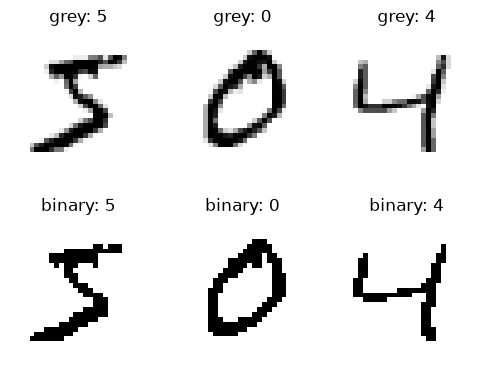

Epoch: 1/20 | Error: 0.2408 | Accuracy: 92.69% | Val Error: 0.1159 | Val Accuracy: 96.21%
Epoch: 2/20 | Error: 0.0933 | Accuracy: 97.10% | Val Error: 0.1070 | Val Accuracy: 96.62%
Epoch: 3/20 | Error: 0.0594 | Accuracy: 98.13% | Val Error: 0.0931 | Val Accuracy: 96.99%
Epoch: 4/20 | Error: 0.0402 | Accuracy: 98.73% | Val Error: 0.0765 | Val Accuracy: 97.74%
Epoch: 5/20 | Error: 0.0249 | Accuracy: 99.25% | Val Error: 0.0838 | Val Accuracy: 97.62%
Training completed.

Final Epoch:
Epoch: 5/20 | Error: 0.0249 | Accuracy: 99.25% | Val Error: 0.0838 | Val Accuracy: 97.62%

  grey | epochs:  5 | train: 99.01% | test: 97.84% | wrong:  216/10000
binary | epochs:  5 | train: 99.25% | test: 97.62% | wrong:  238/10000


In [63]:
BINARY_THRESHOLD = 128


def to_binary_inputs(images):
    return (images.reshape(len(images), -1) >= BINARY_THRESHOLD).astype(float)


binary_train_inputs = to_binary_inputs(train_images)
binary_test_inputs = to_binary_inputs(test_images)

# the same first three images, before (grey) and after (binary) curation
fig, axes = plt.subplots(2, 3, figsize=(6, 4.5))
for i in range(3):
    axes[0, i].imshow(train_images[i], cmap="gray_r")
    axes[0, i].set_title(f"grey: {train_labels[i]}")
    axes[1, i].imshow(binary_train_inputs[i].reshape(IMAGE_SIZE, IMAGE_SIZE), cmap="gray_r")
    axes[1, i].set_title(f"binary: {train_labels[i]}")
for ax in axes.flat:
    ax.axis("off")
plt.show()

network = build_network(BEST_HIDDEN_SIZE, BEST_WEIGHT_RANGE)
binary_trainer = train_network(network, BEST_LEARNING_RATE, binary_train_inputs, binary_test_inputs)

print()
print(f"  grey | {summarize(best_trainer)}")
print(f"binary | {summarize(binary_trainer)}")

#### Averaging over seeds

A single run differs by only a few dozen test images between grey and binary, which is close
to the run-to-run noise. Both inputs are therefore trained with the same 5 seeds (the seed fixes
the initial weights and the shuffle order), and the averages are compared.

In [64]:
import contextlib
import io

SEEDS = [0, 1, 2, 3, 4]
CURATIONS = {
    "grey": (train_inputs, test_inputs),
    "binary": (binary_train_inputs, binary_test_inputs),
}

# (epochs, train accuracy, test accuracy) of every seed, per curation
seed_results = {name: [] for name in CURATIONS}
for seed in SEEDS:
    for name, (train_x, test_x) in CURATIONS.items():
        network = build_network(BEST_HIDDEN_SIZE, BEST_WEIGHT_RANGE, seed=seed)
        # the per-epoch log of all 10 runs is hidden; only each run's final numbers are shown
        with contextlib.redirect_stdout(io.StringIO()):
            trainer = train_network(network, BEST_LEARNING_RATE, train_x, test_x)

        last_epoch = max(trainer.accuracy_by_epoch)
        seed_results[name].append(
            (last_epoch, trainer.accuracy_by_epoch[last_epoch], trainer.validation_accuracy_by_epoch[last_epoch])
        )
        print(f"seed {seed} | {name:>6} | {summarize(trainer)}")

print()
for name, results in seed_results.items():
    epochs, train_accuracy, test_accuracy = np.array(results).T
    print(
        f"{name:>6} average | epochs: {epochs.mean():.1f} | "
        f"train: {train_accuracy.mean():.2%} ± {train_accuracy.std():.2%} | "
        f"test: {test_accuracy.mean():.2%} ± {test_accuracy.std():.2%}"
    )

seed 0 |   grey | epochs:  5 | train: 99.01% | test: 97.84% | wrong:  216/10000
seed 0 | binary | epochs:  5 | train: 99.25% | test: 97.62% | wrong:  238/10000
seed 1 |   grey | epochs:  6 | train: 99.25% | test: 97.93% | wrong:  207/10000
seed 1 | binary | epochs:  5 | train: 99.23% | test: 97.77% | wrong:  223/10000
seed 2 |   grey | epochs:  5 | train: 99.01% | test: 97.97% | wrong:  203/10000
seed 2 | binary | epochs:  5 | train: 99.33% | test: 97.44% | wrong:  256/10000
seed 3 |   grey | epochs:  6 | train: 99.20% | test: 98.30% | wrong:  170/10000
seed 3 | binary | epochs:  5 | train: 99.19% | test: 97.72% | wrong:  228/10000
seed 4 |   grey | epochs:  6 | train: 99.23% | test: 97.99% | wrong:  201/10000
seed 4 | binary | epochs:  5 | train: 99.25% | test: 97.63% | wrong:  237/10000

  grey average | epochs: 5.6 | train: 99.14% ± 0.11% | test: 98.01% ± 0.16%
binary average | epochs: 5.0 | train: 99.25% ± 0.04% | test: 97.64% ± 0.11%


**Results over 5 seeds** (training stops at the first epoch with ≥ 99% train and ≥ 97% test accuracy):

| Seed | Grey epochs | Grey train | Grey test | Binary epochs | Binary train | Binary test |
|---|---|---|---|---|---|---|
| 0 | 5 | 99.01% | 97.84% | 5 | 99.25% | 97.62% |
| 1 | 6 | 99.25% | 97.93% | 5 | 99.23% | 97.77% |
| 2 | 5 | 99.01% | 97.97% | 5 | 99.33% | 97.44% |
| 3 | 6 | 99.20% | 98.30% | 5 | 99.19% | 97.72% |
| 4 | 6 | 99.23% | 97.99% | 5 | 99.25% | 97.63% |
| **Average** | **5.6** | **99.14% ± 0.11%** | **98.01% ± 0.16%** | **5.0** | **99.25% ± 0.04%** | **97.64% ± 0.11%** |

Removing the grey pixels makes the network reach the training goal slightly **faster** (5.0 vs 5.6
epochs, and every binary run finished in 5), but it generalizes slightly **worse**: test accuracy is
lower for all 5 seeds, by 0.37 points on average (about 37 more wrong test images). The difference
is larger than the spread between seeds, so it is a real effect and not noise.

With only 0/1 inputs, images of the same digit look more alike and are easier to fit, so the
training goal is met sooner. But the grey anti-aliased edges (about 18.5% of all pixels) carry
stroke-thickness and faint-stroke detail that helps separate similar digits (4/9, 3/8, 7/1) in
handwriting the network has not seen. The train–test gap grows from 1.13 to 1.61 points, a small
sign of overfitting. The effect is small overall: almost all of the information in an MNIST digit
is in its black-and-white shape.

## Task D — Training too long

The best set-up is trained for a fixed **200 epochs** with every stopping condition removed
(no error threshold, no accuracy targets), so it keeps going long after it reached the goal
in 5 epochs. Training and test accuracy are recorded every epoch and shown as a diagram and
a table.

Epoch: 10/100 | Error: 0.0047 | Accuracy: 99.93% | Val Error: 0.0535 | Val Accuracy: 98.43%
Epoch: 20/100 | Error: 0.0007 | Accuracy: 100.00% | Val Error: 0.0583 | Val Accuracy: 98.53%
Epoch: 30/100 | Error: 0.0004 | Accuracy: 100.00% | Val Error: 0.0608 | Val Accuracy: 98.50%
Epoch: 40/100 | Error: 0.0003 | Accuracy: 100.00% | Val Error: 0.0625 | Val Accuracy: 98.47%
Epoch: 50/100 | Error: 0.0002 | Accuracy: 100.00% | Val Error: 0.0639 | Val Accuracy: 98.48%
Epoch: 60/100 | Error: 0.0002 | Accuracy: 100.00% | Val Error: 0.0651 | Val Accuracy: 98.48%
Epoch: 70/100 | Error: 0.0001 | Accuracy: 100.00% | Val Error: 0.0658 | Val Accuracy: 98.48%
Epoch: 80/100 | Error: 0.0001 | Accuracy: 100.00% | Val Error: 0.0666 | Val Accuracy: 98.48%
Epoch: 90/100 | Error: 0.0001 | Accuracy: 100.00% | Val Error: 0.0674 | Val Accuracy: 98.47%
Epoch: 100/100 | Error: 0.0001 | Accuracy: 100.00% | Val Error: 0.0682 | Val Accuracy: 98.48%
Reached maximum epochs without meeting the error threshold.

Final Epo

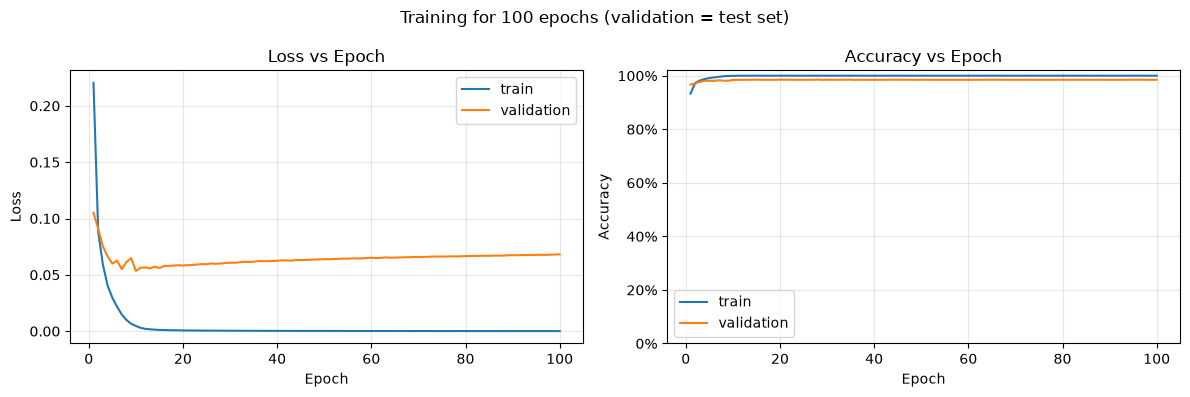

epoch | train loss | test loss | train acc | test acc | test wrong
    1 |     0.2205 |    0.1052 |    93.32% |   96.70% |        330
    5 |     0.0298 |    0.0600 |    99.11% |   98.12% |        188
   10 |     0.0047 |    0.0535 |    99.93% |   98.43% |        157
   25 |     0.0005 |    0.0594 |   100.00% |   98.47% |        153
   50 |     0.0002 |    0.0639 |   100.00% |   98.48% |        152
   75 |     0.0001 |    0.0662 |   100.00% |   98.47% |        153
  100 |     0.0001 |    0.0682 |   100.00% |   98.48% |        152

best test accuracy: 98.53% at epoch 15 (147 of 10000 wrong)
lowest test loss:   0.0535 at epoch 10


In [65]:
from visualizer import TrainingVisualizer

LONG_EPOCHS = 100
BEST_HIDDEN_SIZE = 500
BEST_LEARNING_RATE = 0.3
TABLE_EPOCHS = [1, 5, 10, 25, 50, 75, 100, 125, 150, 175, 200]

long_network = build_network(BEST_HIDDEN_SIZE, BEST_WEIGHT_RANGE)
long_trainer = Trainer(
    long_network,
    learning_rate=BEST_LEARNING_RATE,
    cost=COSTS.CROSS_ENTROPY,
    max_epochs=LONG_EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    report_interval=10,
    error_threshold=None
)
# no target accuracies are passed, so training runs all LONG_EPOCHS epochs
long_trainer.train(train_inputs, train_targets, test_inputs, test_targets)

TrainingVisualizer().plot(long_trainer, title=f"Training for {LONG_EPOCHS} epochs (validation = test set)")

print(f"{'epoch':>5} | {'train loss':>10} | {'test loss':>9} | {'train acc':>9} | {'test acc':>8} | {'test wrong':>10}")
# only the listed epochs that were actually trained, so a shorter LONG_EPOCHS still works
for epoch in [epoch for epoch in TABLE_EPOCHS if epoch <= LONG_EPOCHS]:
    print(
        f"{epoch:>5} | "
        f"{long_trainer.errors_by_epoch[epoch]:>10.4f} | "
        f"{long_trainer.validation_errors_by_epoch[epoch]:>9.4f} | "
        f"{long_trainer.accuracy_by_epoch[epoch]:>9.2%} | "
        f"{long_trainer.validation_accuracy_by_epoch[epoch]:>8.2%} | "
        f"{misclassified(long_trainer.validation_accuracy_by_epoch[epoch]):>10}"
    )

test_accuracy = long_trainer.validation_accuracy_by_epoch
test_loss = long_trainer.validation_errors_by_epoch
best_test_epoch = max(test_accuracy, key=lambda epoch: test_accuracy[epoch])
lowest_test_loss_epoch = min(test_loss, key=lambda epoch: test_loss[epoch])
print(
    f"\nbest test accuracy: {test_accuracy[best_test_epoch]:.2%} at epoch {best_test_epoch} "
    f"({misclassified(test_accuracy[best_test_epoch])} of {len(test_targets)} wrong)"
)
print(f"lowest test loss:   {test_loss[lowest_test_loss_epoch]:.4f} at epoch {lowest_test_loss_epoch}")

### Saving the trained models

Training takes minutes, so both trained networks are written to disk: the best set-up from Task C
(trained until it reached the goal) and the Task D network (trained for `LONG_EPOCHS`). Each file
stores every layer's weights, bias and activation, so the network can be rebuilt later without
training again.

In [69]:
import importlib

import neural_network_np.activations
import neural_network_np.layer
import neural_network_np.network

for module in (neural_network_np.activations, neural_network_np.layer, neural_network_np.network):
    importlib.reload(module)

from neural_network_np.activations import ACTIVATIONS
from neural_network_np.layer import Layer
from neural_network_np.network import Network

# point the already-trained networks at the reloaded classes and activation functions
for trained in (best_network, long_network):
    trained.__class__ = Network
    for layer in trained.layers:
        layer.__class__ = Layer
        activation = ACTIVATIONS.by_name(layer.activation_function.__name__.removesuffix("_function"))
        layer.activation_function = activation.function
        layer.activation_derivative = activation.derivative

print("module file:  ", neural_network_np.network.__file__)
print("has save:     ", hasattr(Network, "save"))
print("networks fixed:", type(best_network) is Network, type(long_network) is Network)


module file:   C:\Users\rlaeh\Documents\GitHub\Artificial_Intelligence\neural_network_np\network.py
has save:      True
networks fixed: True True


In [70]:
MODEL_DIR = Path("models")
BEST_MODEL_PATH = MODEL_DIR / "best_network.npz"
LONG_MODEL_PATH = MODEL_DIR / "long_network.npz"

best_network.save(BEST_MODEL_PATH)
long_network.save(LONG_MODEL_PATH)
print(f"saved {BEST_MODEL_PATH} and {LONG_MODEL_PATH}")

saved models\best_network.npz and models\long_network.npz


### Loading a saved model

The saved network is loaded back and scored on the test set. It gives the same accuracy as the
network that was trained, so the later tasks can start from this cell instead of retraining
(after running the setup cells of Task A and C).

In [71]:
def test_accuracy_of(network):
    predictions = np.argmax(network.forward(test_inputs), axis=1)
    return np.mean(predictions == test_labels)


loaded_network = Network.load(BEST_MODEL_PATH)

accuracy = test_accuracy_of(loaded_network)
print(f"loaded {BEST_MODEL_PATH}: {[layer.weights.shape for layer in loaded_network.layers]}")
print(f"test accuracy: {accuracy:.2%} ({misclassified(accuracy)} of {len(test_targets)} wrong)")

loaded models\best_network.npz: [(300, 784), (10, 300)]
test accuracy: 97.84% (216 of 10000 wrong)


## Task E — Inputs that are not digits

The Task D network (`long_network`, trained far past the goal) is loaded from disk and fed three
inputs that are not digits. The output layer is a softmax, so whatever the input, the network must
spread exactly 100% of its belief over the digits 0–9 — there is no "none of the above". The
question is how confidently it picks a digit anyway.

The three inputs, each on the same 0–1 scale as the training images:

1. **Random noise** — every pixel an independent random grey level.
2. **A smiley face** — a drawn shape with round strokes like a 0, but eyes and a mouth inside.
3. **An inverted digit** — the first test image (a real 7) with black and white swapped, so it is
   a white digit on an all-ink background.

### Predictions (before running)

- **Random noise:** *…your prediction: which digit, and how confident?…*
- **Smiley face:** *…*
- **Inverted digit:** *…*

loaded models\long_network.npz: [(500, 784), (10, 500)]
random noise               -> 8 with 73.00% (runner-up 0 with 23.24%, probabilities sum to 1.000)
smiley face                -> 2 with 99.87% (runner-up 3 with 0.09%, probabilities sum to 1.000)
inverted test digit (a 7)  -> 5 with 95.62% (runner-up 9 with 2.04%, probabilities sum to 1.000)


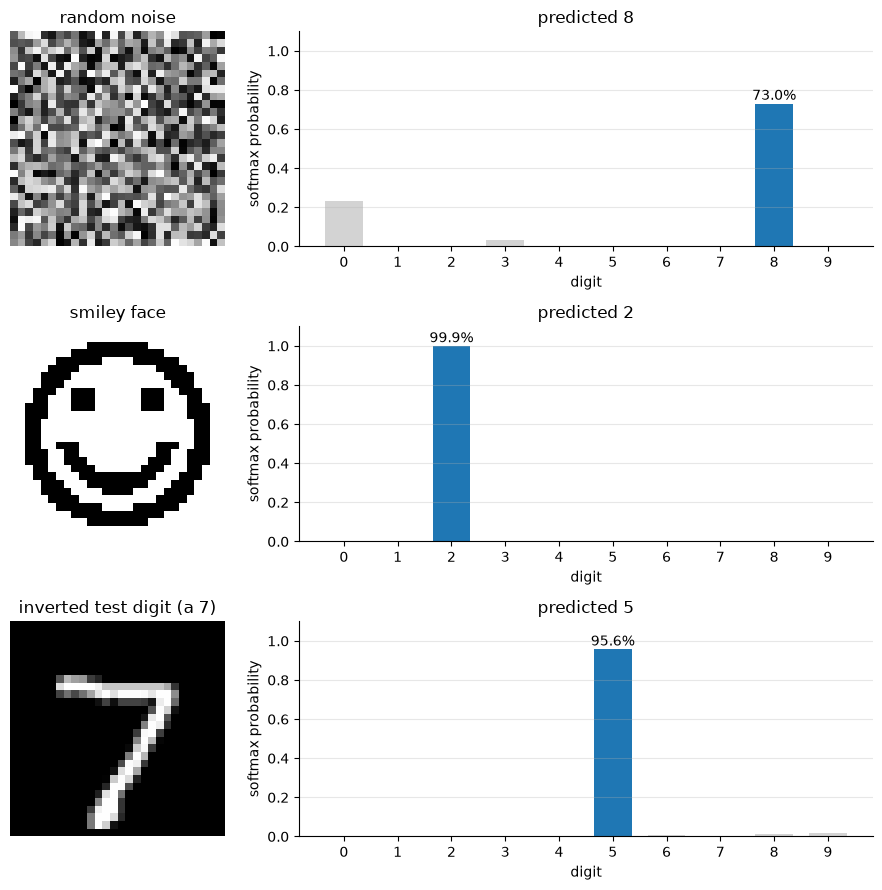

In [72]:
task_e_network = Network.load(LONG_MODEL_PATH)
print(f"loaded {LONG_MODEL_PATH}: {[layer.weights.shape for layer in task_e_network.layers]}")

rows, cols = np.mgrid[:IMAGE_SIZE, :IMAGE_SIZE]
center = (IMAGE_SIZE - 1) / 2
distance_from_center = np.hypot(rows - center, cols - center)


def smiley_face():
    face = np.abs(distance_from_center - 11) < 1.2
    eyes = (np.hypot(rows - 9, cols - 9) < 2) | (np.hypot(rows - 9, cols - 18) < 2)
    mouth = (np.abs(distance_from_center - 6.5) < 1.2) & (rows > center + 1)
    return (face | eyes | mouth).astype(float)


TASK_E_INPUTS = {
    "random noise": np.random.default_rng(0).random((IMAGE_SIZE, IMAGE_SIZE)),
    "smiley face": smiley_face(),
    f"inverted test digit (a {test_labels[0]})": 1 - test_images[0] / 255.0,
}

fig, axes = plt.subplots(len(TASK_E_INPUTS), 2, figsize=(9, 3 * len(TASK_E_INPUTS)), gridspec_kw={"width_ratios": [1, 2.5]})
for (name, image), (image_ax, bar_ax) in zip(TASK_E_INPUTS.items(), axes):
    probabilities = task_e_network.forward(image.reshape(1, -1))[0]
    predicted = int(np.argmax(probabilities))
    runner_up = int(np.argsort(probabilities)[-2])

    image_ax.imshow(image, cmap="gray_r", vmin=0, vmax=1)
    image_ax.set_title(name)
    image_ax.axis("off")

    # the predicted digit is the one accent bar; every other digit stays grey
    colors = ["tab:blue" if digit == predicted else "lightgray" for digit in range(NUM_CLASSES)]
    bar_ax.bar(range(NUM_CLASSES), probabilities, color=colors, width=0.7)
    bar_ax.text(predicted, probabilities[predicted] + 0.02, f"{probabilities[predicted]:.1%}", ha="center")
    bar_ax.set_xticks(range(NUM_CLASSES))
    bar_ax.set_ylim(0, 1.1)
    bar_ax.set_xlabel("digit")
    bar_ax.set_ylabel("softmax probability")
    bar_ax.set_title(f"predicted {predicted}")
    bar_ax.grid(axis="y", alpha=0.3)
    bar_ax.spines[["top", "right"]].set_visible(False)

    print(
        f"{name:<26} -> {predicted} with {probabilities[predicted]:.2%} "
        f"(runner-up {runner_up} with {probabilities[runner_up]:.2%}, probabilities sum to {probabilities.sum():.3f})"
    )

fig.tight_layout()
plt.show()

### Observations

*…compare each result with your prediction…*